<a href="https://colab.research.google.com/github/wVks/mipt_speech_technology_25_maksim_fetisov/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [435]:
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt

In [436]:
def hz_to_mel(frequency):
    """Преобразование Гц в мел"""
    return 2595 * np.log10(1 + frequency / 700)

def mel_to_hz(mel):
    """Преобразование мел в Гц"""
    return 700 * (10 ** (mel / 2595) - 1)

In [437]:
audio_path = "/content/Snares_Look.mp3"

audio, original_sr = sf.read(audio_path)

print(f"Форма: {audio.shape}")
print(f"Исходная частота: {original_sr} Hz")
print(f"Длительность аудио: {len(audio)/original_sr:.2f} секунд")

Форма: (1392768, 2)
Исходная частота: 44100 Hz
Длительность аудио: 31.58 секунд


In [438]:
# Преобразование в моно
if len(audio.shape) > 1:
    audio = np.mean(audio, axis=1)

# Нормализация
audio = audio / np.max(np.abs(audio))

Mel-фильтры

In [439]:
SAMPLE_RATE = original_sr #44100 Частота дискретизации в Гц
N_FFT = 2400 # Размер окна в сэмплах
HOP_LENGTH = 440 # Шаг между окнами
N_MELS = 128 # Количество фильтров
FMIN = 0 # Минимальная частота
FMAX = 10500 # Максимальная частота

# Создаем mel-фильтры
mel_min = hz_to_mel(FMIN)
mel_max = hz_to_mel(FMAX)
mel_points = np.linspace(mel_min, mel_max, N_MELS + 2)
hz_points = mel_to_hz(mel_points)

# Преобразуем в бины FFT
fft_bins = np.floor((N_FFT + 1) * hz_points / SAMPLE_RATE).astype(int)

# Создаем матрицу треугольных фильтров
mel_filters = np.zeros((N_MELS, N_FFT // 2 + 1))

for i in range(N_MELS):
    left = fft_bins[i]
    center = fft_bins[i + 1]
    right = fft_bins[i + 2]

    # Треугольный фильтр
    if left < center:
        mel_filters[i, left:center] = np.linspace(0, 1, center - left)
    if center < right:
        mel_filters[i, center:right] = np.linspace(1, 0, right - center)

# Нормализация фильтров
mel_filters = mel_filters / np.maximum(np.sum(mel_filters, axis=1, keepdims=True), 1e-10)

print(f"Частотный диапазон: {FMIN}-{FMAX} Hz")
print(f"{mel_filters.shape[0]} фильтров × {mel_filters.shape[1]} частотных бинов")

Частотный диапазон: 0-10500 Hz
128 фильтров × 1201 частотных бинов


In [440]:
frame_length_ms = (N_FFT / SAMPLE_RATE) * 1000
hop_length_ms = (HOP_LENGTH / SAMPLE_RATE) * 1000
print(f"Длина окна: {frame_length_ms:.1f} мс")
print(f"Шаг окна: {hop_length_ms:.1f} мс")
print(f"Перекрытие: {frame_length_ms - hop_length_ms:.1f} мс")

Длина окна: 54.4 мс
Шаг окна: 10.0 мс
Перекрытие: 44.4 мс


STFT (Кратковременное преобразование Фурье)

In [441]:
audio_padded = np.pad(audio, (N_FFT // 2, N_FFT // 2), mode='reflect')

# Оконная функция Ханна
window = 0.5 * (1 - np.cos(2 * np.pi * np.arange(N_FFT) / (N_FFT - 1)))

# Количество временных фреймов
n_frames = 1 + (len(audio_padded) - N_FFT) // HOP_LENGTH

# Вычисляем STFT для каждого фрейма
stft_result = np.zeros((N_FFT // 2 + 1, n_frames), dtype=np.complex128)

for i in range(n_frames):
    start = i * HOP_LENGTH
    end = start + N_FFT
    frame = audio_padded[start:end] * window
    stft_result[:, i] = np.fft.fft(frame)[:N_FFT // 2 + 1]

print(f"STFT: {stft_result.shape}")
print(f"{stft_result.shape[0]} частот × {stft_result.shape[1]} фреймов")

STFT: (1201, 3166)
1201 частот × 3166 фреймов


In [442]:
# Спектр мощности
power_spectrogram = np.abs(stft_result) ** 2
print(f"Спектр мощности: {power_spectrogram.shape}")

# Применяем mel-фильтры
mel_spectrogram = np.dot(mel_filters, power_spectrogram)

# Преобразование в децибелы (логарифмическая шкала)
def power_to_db(spectrogram, ref=1.0):
    return 10.0 * np.log10(np.maximum(spectrogram, 1e-10)) - 10.0 * np.log10(np.maximum(ref, 1e-10))

mel_spectrogram_db = power_to_db(mel_spectrogram)

print(f"Mel-спектрограмма: {mel_spectrogram_db.shape}")
print(f"Диапазон значений: {np.min(mel_spectrogram_db):.1f} dB до {np.max(mel_spectrogram_db):.1f} dB")

Спектр мощности: (1201, 3166)
Mel-спектрограмма: (128, 3166)
Диапазон значений: -100.0 dB до 50.9 dB


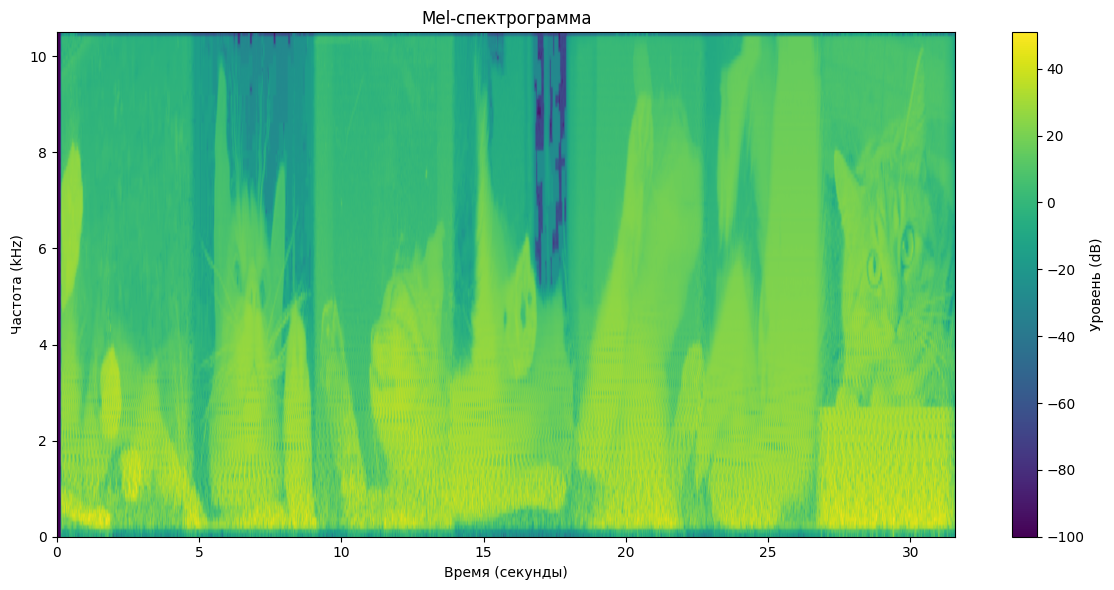

In [443]:
time_axis = np.arange(mel_spectrogram_db.shape[1]) * HOP_LENGTH / SAMPLE_RATE
freq_axis = np.linspace(0, FMAX/1000, mel_spectrogram_db.shape[0])

plt.figure(figsize=(12, 6))
plt.imshow(mel_spectrogram_db,
           aspect='auto',
           origin='lower',
           extent=[time_axis[0], time_axis[-1], freq_axis[0], freq_axis[-1]],
           cmap='viridis')

plt.colorbar(label='Уровень (dB)')
plt.xlabel('Время (секунды)')
plt.ylabel('Частота (kHz)')
plt.title('Mel-спектрограмма')
plt.tight_layout()
plt.show()